In [ ]:
pip install atproto numpy pandas matplotlib networkx scipy nltk tabulate emoji scikit-learn transformers torch pyldavis wordcloud jupyter ipywidgets

# Social Media and Network Analytics - Assignment 2
## Our Question:
- What are peoples limits to Ai generated content in video games?

## Files and Directories:
- Our dataset folder contains all of the json data we have worked with and graphml files we have generated
- Our graphs folder the graphs we have generated for networks and communities using networkx or gephi

## Team Members:
- Mitchell Long: S4007880
- Jimmy Vu: S4006701
- Khang Nguyen: S4005711

In [ ]:
from atproto import Client
from account import getAccount
import emoji
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
import json
import re
import pandas as pd
from collections import Counter
import tabulate
import matplotlib.pyplot as plt
from transformers import pipeline
import numpy as np
import math

import pyLDAvis
import pyLDAvis.lda_model
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

In [34]:
datasetPath = "./dataset/"
searchQueries = [
    "Gen AI, AI, games", 
    "Gen AI, AI, Larian", 
    "Gen AI, AI, Expedition 33", 
    "Gen AI, AI, Battlefield 6", 
    "Gen AI, AI, Shift Up",
    "Generative AI, Games",
    "Generative AI, Games, Good",
    "Generative AI, Games, Bad",
    "AI Slop, Games",
    ]

# Currently set as False to not override json data
getData = False

### Data Collection and Formatting

In [ ]:
# Running this block will prompt user input for username and password
# Keeping this separate allows us to use client apis later in the notebook 
# without needing to recollect data again
username, password = getAccount()
client = Client()
client.login(username, password)

In [19]:
# Run a search query and collect postst
# getData will need to be set to True earlier for us to run this section 
# getData currently set to false to not override our data json file
if (getData):
        
    structured_posts = []
    for q in searchQueries:
        search_results = client.app.bsky.feed.search_posts({"q": q, "limit": 100})
        display(search_results)

        # Iterate through each collected post and its replies
        for post in search_results.posts:

            # Print posts for output proof
            name = post.author.display_name

            if name is None:
                name = post.author.handle
                
            print(name + ": ")
            print(post.record.text)
            print('\n')

            # Fetch thread for this post using the uri
            thread = client.app.bsky.feed.get_post_thread({
                "uri": post.uri
            })

            replies_data = []

            replies = getattr(thread.thread, "replies", [])

            # Create JSON structure for each reply
            for reply in replies:
                if hasattr(reply, "post"):

                    reply_post = reply.post

                    replies_data.append({
                        "reply_id": reply_post.uri,
                        "text": reply_post.record.text,
                        "created_at": getattr(reply_post.record, "created_at", None),

                        "author": {
                            "display_name": reply_post.author.display_name,
                            "handle": reply_post.author.handle
                        },

                        "engagement": {
                            "likes": reply_post.like_count,
                            "replies": reply_post.reply_count,
                            "reposts": reply_post.repost_count
                        }
                    })

            # Create JSON structure for original post and append comments
            structured_post = {
                "post_id": post.uri,
                "text": post.record.text,
                "created_at": getattr(post.record, "created_at", None),

                "author": {
                    "display_name": post.author.display_name,
                    "handle": post.author.handle,
                    "did": post.author.did
                },

                "engagement": {
                    "likes": post.like_count,
                    "reposts": post.repost_count,
                    "replies": post.reply_count,
                    "quotes": post.quote_count
                },

                "metadata": {
                    "lang": getattr(post.record, "langs", [])
                },

                # Comments appended here
                "comments": replies_data
            }

            # Add posts to one object
            structured_posts.append(structured_post)

        # Create and save data to JSON file
        data = {'posts': structured_posts}

    with open(datasetPath + "bluesky_posts.json", "w", encoding="utf-8") as file:
        json.dump(data, file, indent=4, ensure_ascii=False)

Response(posts=[PostView(author=ProfileViewBasic(did='did:plc:4qrq2iglr73kq3ya7nl6pphm', handle='alanbaxter.bsky.social', associated=ProfileAssociated(activity_subscription=ProfileAssociatedActivitySubscription(allow_subscriptions='followers', py_type='app.bsky.actor.defs#profileAssociatedActivitySubscription'), chat=ProfileAssociatedChat(allow_incoming='all', py_type='app.bsky.actor.defs#profileAssociatedChat'), feedgens=None, labeler=None, lists=None, starter_packs=None, py_type='app.bsky.actor.defs#profileAssociated'), avatar='https://cdn.bsky.app/img/avatar/plain/did:plc:4qrq2iglr73kq3ya7nl6pphm/bafkreiei4bi6wxep3p7aux6wyxs5dgn27pmphzdozyqmvreuwjlbkjg7lm', created_at='2023-05-02T22:58:58.071Z', debug=None, display_name='Alan Baxter', labels=[], pronouns=None, status=None, verification=VerificationState(trusted_verifier_status='none', verifications=[VerificationView(created_at='2025-11-07T04:54:40.874Z', is_valid=True, issuer='did:plc:z72i7hdynmk6r22z27h6tvur', uri='at://did:plc:z72

Alan Baxter: 
It does indeed belittle all of those things. I bet a Venn diagram of people who like the idea of the enhanced games and people who like gen-ai is a circle.


bubba the dog: 
UE6 running how it's going to run will require frame gen to straight up make shit up due to lack of real frames and this is how they will force AI games on us


EKK0💽: 
one of the saddest parts of gen ai becoming prominent is all the funny porno games on steam are just ai now. used to be you had to at least draw or blender the art to put out 5 dollar Super Wife Fucker Adventures


Curiouser LLC: 
Hey! If you’re interested in Gen AI and games and the safety issues of millions of people chatting with live AI my GDC talk is up for free. Check it out! #AI #gamedev #gdc


Ciro | Veilguard 31st October | Elf simp: 
MORE games are using gen ai than ppl think. The problem is that their main target audience doesn't actually care so nothing will happen.
This will keep going until it's so much slop you can't loo

Response(posts=[PostView(author=ProfileViewBasic(did='did:plc:f7m6nr5c4l4huulf4vd54vrn', handle='graylady-seesall05.bsky.social', associated=ProfileAssociated(activity_subscription=ProfileAssociatedActivitySubscription(allow_subscriptions='followers', py_type='app.bsky.actor.defs#profileAssociatedActivitySubscription'), chat=None, feedgens=None, labeler=None, lists=None, starter_packs=None, py_type='app.bsky.actor.defs#profileAssociated'), avatar='https://cdn.bsky.app/img/avatar/plain/did:plc:f7m6nr5c4l4huulf4vd54vrn/bafkreicrcublyrhvpx23jivu2gbd5ntrauwhxft2ebdxi6ofnhnmvh7tre', created_at='2025-10-22T23:20:03.017Z', debug=None, display_name='The Gray Lady', labels=[], pronouns=None, status=None, verification=None, viewer=ViewerState(activity_subscription=None, blocked_by=False, blocking=None, blocking_by_list=None, followed_by=None, following=None, known_followers=None, muted=False, muted_by_list=None, py_type='app.bsky.actor.defs#viewerState'), py_type='app.bsky.actor.defs#profileView

The Gray Lady: 
I remember something about Larian Studios saying they would be using gen ai to inspire their concept art but wouldn’t put it in their concept art…I still found that silly and wrong. They would still be using and supporting something that steals from artists. I hope what I heard was wrong


mona 🗡️🐋: 
idk if im gonne get divinty larian said theyre using gen ai in early development and im disappointed 👎 but yes… i need something….. i wanted to play mass effect again but ofc the ea app is not letting me log in


wispy 🥐: 
I made a little petition and will send it around and I'll send it to Larian once we get enough signatures! ✏️

www.change.org/p/dear-laria...


Duck AI Slop!!: 
Larian Studios
Divinity will have gen-ai tools used for idea's and concept, pulling back from 'concept art' after backlash but won't rule out the team using it, and "won't be in the final version of Divinity." -y
Sources:
www.polygon.com/larian-addre...

www.thegamer.com/larian-backt...


elitsa ✨

Response(posts=[PostView(author=ProfileViewBasic(did='did:plc:nrabop3v7a6qf53py77ot7g5', handle='vapormelon.bsky.social', associated=ProfileAssociated(activity_subscription=ProfileAssociatedActivitySubscription(allow_subscriptions='followers', py_type='app.bsky.actor.defs#profileAssociatedActivitySubscription'), chat=None, feedgens=None, labeler=None, lists=None, starter_packs=None, py_type='app.bsky.actor.defs#profileAssociated'), avatar='https://cdn.bsky.app/img/avatar/plain/did:plc:nrabop3v7a6qf53py77ot7g5/bafkreicequdu4l4phm47loclc6lr2477h5zmnxl55u6sfiow3cxwbon6m4', created_at='2025-02-20T01:51:26.613Z', debug=None, display_name='Melon', labels=[], pronouns=None, status=None, verification=None, viewer=ViewerState(activity_subscription=None, blocked_by=False, blocking=None, blocking_by_list=None, followed_by=None, following=None, known_followers=None, muted=False, muted_by_list=None, py_type='app.bsky.actor.defs#viewerState'), py_type='app.bsky.actor.defs#profileViewBasic'), cid='ba

...

Bjorn BookLab: 
AI in games will explode this year. Most studios are pivoting.
We are very close to getting models that are good enough for production ready 3d models. Concept Art is already 90%+ promoting generative AI. Tools development is accelerating thanks to Claude.
Small skilled teams can do more with less.


🔞 Alishya 🔞: 
Ai that isn’t bullshit generative nonsense built for gutting the working class is good and fine. (Ai in games; as an easy example)

All forms of generative ai, llms, etc etc are garbage. I really feel like they co-opted the ai tag to make this discourse


Techmeme X Chatter: 
This tweet appeared under this Techmeme headline:

Ben / @videotech:

@asha_shar This is exactly what Xbox needs. This AI push will not work out. I'm glad you're understand this. Hopefully more focus on hardware and games and not generative AI nonsense. This is a good step again


SuperGamer61499 🔞: 
Is it some Gacha game? That could be why I NEVER heard of it. I don't care for Gachas. Th

Response(posts=[PostView(author=ProfileViewBasic(did='did:plc:h2pce2qp2ku7ezrdx45emjf3', handle='mp1st.bsky.social', associated=ProfileAssociated(activity_subscription=ProfileAssociatedActivitySubscription(allow_subscriptions='followers', py_type='app.bsky.actor.defs#profileAssociatedActivitySubscription'), chat=ProfileAssociatedChat(allow_incoming='following', py_type='app.bsky.actor.defs#profileAssociatedChat'), feedgens=None, labeler=None, lists=None, starter_packs=None, py_type='app.bsky.actor.defs#profileAssociated'), avatar='https://cdn.bsky.app/img/avatar/plain/did:plc:h2pce2qp2ku7ezrdx45emjf3/bafkreiabzso4sfjn4twweb4hp4vz3rpwigpswi4lfag257u45iwp6vc32m', created_at='2024-09-04T22:33:56.266Z', debug=None, display_name='MP1st', labels=[], pronouns=None, status=None, verification=None, viewer=ViewerState(activity_subscription=None, blocked_by=False, blocking=None, blocking_by_list=None, followed_by=None, following=None, known_followers=None, muted=False, muted_by_list=None, py_type

MP1st: 
Capcom admits it is using generative AI in games development. but it's not as bad as you think.

mp1st.com/news/capcom-...


Ben Lubar (any pronouns): 
is it really this bad

how many browser-based games were on itch before generative AI


Becca: 
Replied to a comment on TikTok explaining why using generative AI in games is bad for multiple reasons

The creator of the video blocked me because they use gen AI in their games LMFAO


Bad Squiddo Games (Annie): 
OK FOLKS! Want to w in THE SAMPLER BOOK from the upcoming @handiworkgames.bsky.social KS? *and* a Bad Squiddo voucher?

Photo our minis on a Jon backdrop, tag #jhbackdrops @badsquiddogames.bsky.social @handiworkgames.bsky.social 

All the T&C in this link:
badsquiddogames.com/blog/photo-c...


Jo: 
It's not *as* bad when you actually scroll down. On top of that, AI is banned for all games sold through the actual Playdate Catalog.


Mode 7: 
How did Level 5 fumble so bad bro? Like what do you mean a company that made such ch

Response(posts=[PostView(author=ProfileViewBasic(did='did:plc:nnisa44lmte6rxxmf5f4ccba', handle='eriugam.bsky.social', associated=ProfileAssociated(activity_subscription=ProfileAssociatedActivitySubscription(allow_subscriptions='followers', py_type='app.bsky.actor.defs#profileAssociatedActivitySubscription'), chat=None, feedgens=None, labeler=None, lists=None, starter_packs=None, py_type='app.bsky.actor.defs#profileAssociated'), avatar='https://cdn.bsky.app/img/avatar/plain/did:plc:nnisa44lmte6rxxmf5f4ccba/bafkreihq7vlvbhkv3xybpxttsphg53rglro3n5jqdw5nufmr3rrf57cxym', created_at='2024-06-15T00:03:18.440Z', debug=None, display_name='Eri', labels=[Label(cts='2024-06-15T00:03:20.055Z', src='did:plc:nnisa44lmte6rxxmf5f4ccba', uri='at://did:plc:nnisa44lmte6rxxmf5f4ccba/app.bsky.actor.profile/self', val='!no-unauthenticated', cid='bafyreieyytknbiywn6djdih4czhto6xkw67k5lghaut7e7boerpgqqpy4y', exp=None, neg=None, sig=None, ver=None, py_type='com.atproto.label.defs#label')], pronouns=None, statu

Eri: 
I criticise games now, before the inevitable AI slop starts creeping into them.

Humans make equally as bad digital media.


Another Terrible Idea: 
Level One is gets a ton of props as far as barcodes in town go just for actually caring about games enough to show Combo Breaker on one of their TVs. No others bothered to do that over the years. 

Thumbs down for their AI slop advertising, though. 

My MMPR sticker and buddies shown here!


🪄 Naomi "Note Worthy" Slover: 
This sounds kinda dope, if they can make it a successful technology over time.

Before GenAI slop showed up everywhere, we HAD AI engines in our video games and thought little of it.


restlessBear: 
I have a good sized library of games, I don't need more. I'm not giving you money for a game unless you make the effort to say you're rejecting the use of theft and plagiarism ai slop generators.


restlessBear: 
I had five games in my Steam cart from my wishlist. After review, I'm down to one. The other four either a) 

# Part 1 Analysis - Network Connections
Resort the json by likes so we can collect network of the most influential posts

In [20]:
with open(datasetPath + "bluesky_posts.json", "r") as file:
    data = json.load(file)

data["posts"].sort(
    key=lambda post: post["engagement"]["likes"],
    reverse=True
)

with open(datasetPath + "sorted_bluesky_posts.json", "w", encoding="utf-8") as file:
    json.dump(data, file, indent=4, ensure_ascii=False)

Time to collect followers and following from the top most liked posts

In [35]:
# HEADS UP THIS PART TAKES A LONG TIME AS IT IS RUNNING MANY API CALLS TO COLLECT COUNTS
# Run the sorting cell before running this cell
with open(datasetPath + "sorted_bluesky_posts.json", "r") as file:
    data = json.load(file)

posts = data["posts"]

# Here sets how many posts (Currently at top 50 posts)
top_posts = posts[:50]

results = []

for post in top_posts:
    # We will use the did to differenciate from accounts as it is unique
    did = post["author"]["did"]

    handle = post["author"]["handle"]

    print(f"Fetching: {handle}")

    # We collect the handles for better displaying once we put it in graphs
    try:
        # Collecting counts of followers and following
        profile = client.app.bsky.actor.get_profile({
            "actor": did
        })

        print("Followers:", profile.followers_count)
        print("Following:", profile.follows_count)
        
        # followers
        followers_response = client.app.bsky.graph.get_followers({
            "actor": did,
            "limit": 100
        })

        # follows
        follows_response = client.app.bsky.graph.get_follows({
            "actor": did,
            "limit": 100
        })

        # Loop through each follower and following to get their counts as well
        followers = []

        for user in followers_response.followers:
            profile = client.app.bsky.actor.get_profile({
                "actor": user.did
            })

            print("Followers:", profile.followers_count)
            followers.append({"user": user.handle, "followers_count": profile.followers_count})

        following = []

        for user in follows_response.follows:
            profile = client.app.bsky.actor.get_profile({
                "actor": user.did
            })

            print("Followers:", profile.followers_count)
            following.append({"user": user.handle, "followers_count": profile.followers_count})

        results.append({
            "handle": handle,
            "did": did,
            "followers_count": profile.followers_count,
            "following_count": profile.follows_count,
            "followers": followers,
            "following": following
        })

    except Exception as e:
        print(f"Error with {handle}: {e}")

# ---------------------------------
# save output
# ---------------------------------
with open(datasetPath + "user_follows.json", "w", encoding="utf-8") as file:
    json.dump(results, file, indent=2, ensure_ascii=False)

Fetching: triple-q.bsky.social
Followers: 10733
Following: 130
Followers: 18
Followers: 9
Followers: 35
Followers: 28
Followers: 229
Followers: 7
Followers: 52
Followers: 837
Followers: 271
Followers: 833
Followers: 165
Followers: 218
Followers: 1855
Followers: 1385
Followers: 489
Followers: 69
Followers: 59
Followers: 112
Followers: 478
Followers: 3
Followers: 16
Followers: 1
Followers: 1095
Followers: 15313
Followers: 23
Followers: 11
Followers: 4140
Followers: 850
Followers: 5
Followers: 672
Followers: 275
Followers: 235
Followers: 21
Followers: 24
Followers: 39
Followers: 408
Followers: 87
Followers: 143
Followers: 75
Followers: 13
Followers: 253
Followers: 10
Followers: 86
Followers: 74
Followers: 1763
Followers: 222
Followers: 255
Followers: 44
Followers: 55
Followers: 1217
Followers: 104
Followers: 100
Followers: 355
Followers: 55
Followers: 1
Followers: 583
Followers: 28
Followers: 153
Followers: 83
Followers: 7
Followers: 13
Followers: 22609
Followers: 203
Followers: 327
Follo

### Visualising Network Communities
Workshop code taken from Week7 as a basis:


In [36]:
import networkx as nx

# Lets display the network of the most liked post author
with open(datasetPath + "user_follows.json", "r", encoding="utf-8") as file:
    data = json.load(file)

egoGraph = nx.DiGraph()

for egoUser in data:
    egoName = egoUser["handle"]
    egoGraph.add_node(egoName, followers=egoUser["followers_count"])

    # followers we have collected earlier
    # we point creator towards follower instead to show influence and for independent cascade
    for follower in egoUser["followers"]:
            # add follower to graph
            # first add node then add the edge
            egoGraph.add_node(follower["user"], followers=follower["followers_count"])

            egoGraph.add_edge(egoName, follower["user"])

    for following in egoUser["following"]:
        # add follower to graph
        # first add node then add the edge
        egoGraph.add_node(following["user"], followers=following["followers_count"])

        egoGraph.add_edge(following["user"], egoName)

Some Network Analysis related to an ego

In [38]:
# Save graph to file with directions
graphFile=datasetPath + 'communityNetwork.graphml'

with open(datasetPath + "user_follows.json", "r", encoding="utf-8") as file:
    data = json.load(file)
    
first_nodeUser = data[0]["handle"]

# Lets print out the network of the first user to demonstrate the connections created
inDeg = egoGraph.in_degree(first_nodeUser)
outDeg = egoGraph.out_degree(first_nodeUser)

print('in degree of ego = {}'.format(inDeg))
print('out degree of ego = {}'.format(outDeg))

lInNeighbours = [sNeigh for sNeigh in egoGraph.predecessors(first_nodeUser)]
lOutNeighbours = [sNeigh for sNeigh in egoGraph.successors(first_nodeUser)]

# This essentially goes through the in neighbours list and outputs them one by one
print('in neighbours of ego = {', end='')
print(*lInNeighbours, sep=', ', end='')
print('}')

print('out neighbours of ego = {', end='')
print(*lOutNeighbours, sep=', ', end='')
print('}')

# this code outputs the graph as graphml format, which can be then visualised by an external program
with open(graphFile, 'wb') as fOut:
    nx.write_graphml(egoGraph, fOut)

in degree of ego = 99
out degree of ego = 100
in neighbours of ego = {taiyangyu.bsky.social, bitesize.bsky.social, lennyizquierdo.bsky.social, lhata4564.bsky.social, lovelivenews.bsky.social, persona.bsky.social, gofasheadbox.bsky.social, omknee.bsky.social, mcbedti.me, ezfollowers.xyz, samipeko.bsky.social, nanya000.bsky.social, celebelian.bsky.social, sarveproductions.bsky.social, fuchsiaa.bsky.social, arkestar.bsky.social, timelesst2.bsky.social, inputwo.bsky.social, warframe.com, chuunioniika.bsky.social, sifserf.bsky.social, bxxdhere.bsky.social, fortnite-status.bsky.social, fortnite-game.bsky.social, fngame-status.bsky.social, tonycomputerentertainment.com, sonic-official.bsky.social, ktullanyx.bsky.social, mcmangos.bsky.social, hugeldude.bsky.social, anchet7.bsky.social, summitsphere.com, kevinfagaragan.bsky.social, gurumie.bsky.social, highquality.rip, fracktail.bsky.social, bonoshii.bsky.social, yuzulo.bsky.social, colorgeist.bsky.social, dkirbyj.bsky.social, nekotj.bsky.socia

# Visualising the Ego Net
We show off a multi ego network to display network following and followers

More code from workshop 7 used as a basis:

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# We have set up a multi ego network of 50 users
lInNeighbours = set()
lOutNeighbours = set()

node_colors = []
node_sizes = []

egoUsers = {
    user["handle"]
    for user in data
}

for ego in egoUsers:
    # Following
    lInNeighbours.update(
        egoGraph.predecessors(ego)
    )

    # Followers
    lOutNeighbours.update(
        egoGraph.successors(ego)
    )

for n in egoGraph.nodes():
    if n in egoUsers:
        node_colors.append("gold")
        node_sizes.append(3000)
    else:
        in_only = (n in lInNeighbours) and (n not in lOutNeighbours)
        out_only = (n in lOutNeighbours) and (n not in lInNeighbours)
        both = (n in lInNeighbours) and (n in lOutNeighbours)

        if both:
            node_colors.append("mediumpurple")
        elif in_only:
            node_colors.append("skyblue")
        elif out_only:
            node_colors.append("lightcoral")
        else:
            node_colors.append("lightgray")

        # We influence node size by follower count
        followers = egoGraph.nodes[n].get("followers", 0)
        node_sizes.append(100 + 0.05 * followers)

plt.figure(figsize=(140, 110))
pos = nx.spring_layout(egoGraph, seed=42, k=1.2)

nx.draw_networkx_nodes(
    egoGraph,
    pos,
    node_color=node_colors,
    node_size=node_sizes
)

nx.draw_networkx_edges(
    egoGraph,
    pos,
    arrows=True
)

nx.draw_networkx_labels(
    egoGraph,
    pos,
    font_size=25
)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='ego',
           markerfacecolor='gold', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='in-only',
           markerfacecolor='skyblue', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='out-only',
           markerfacecolor='lightcoral', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='both',
           markerfacecolor='mediumpurple', markersize=12)
]

plt.legend(handles=legend_elements, loc='best')
plt.axis("off")
plt.show()

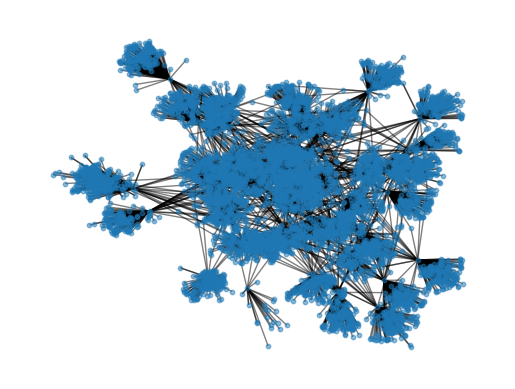

In [40]:
#
# Draw graph
#

from matplotlib.patches import ArrowStyle

# use networkx to draw
# opt for a smaller node size than the default 300 as it is too much and also removal of with labels taking too much space
nx.draw_networkx(egoGraph, pos=nx.spring_layout(egoGraph, seed=42), arrows=False, with_labels=False, node_size=10, alpha=0.5)
plt.axis('off')
plt.show()

## Reply graph contruction
Week 9 code as basis:

In [21]:
import pandas as pd
import networkx as nx
import json 

#load data

with open(datasetPath + "sorted_bluesky_posts.json" , "r") as Jfile:
    data = json.load(Jfile)

posts = data["posts"]

rows = []

for post in posts:
    post_id = post["post_id"]
    author_handle = post["author"]["handle"]

    for com in post.get("comments", []):
        rows.append({
            "comment_id": com["reply_id"],
            "author": com["author"]["handle"],
            "parent_id": post_id,
            "thread_id": post_id,
            "is_author": False
        })

    rows.append({
    
        "comment_id": post_id,
        "author": author_handle,
        "parent_id": post_id,
        "thread_id": post_id,
        "is_author": True
    }
    )

df = pd.DataFrame(rows)
df = df.dropna(subset=["author", "comment_id", "parent_id", "thread_id"])
df = df.astype({
    "author":str,
    "comment_id": str,
    "parent_id": str,
    "thread_id" : str
})

num_threads = 50

selected_threads = df["thread_id"].unique()[:num_threads]
df = df[df["thread_id"].isin(selected_threads)]

print(df.shape)
print("Num of threads: ", df["thread_id"].nunique())


(409, 5)
Num of threads:  50


In [22]:
# Only comments
id2author = dict(zip(df[df["is_author"] == False]["comment_id"],
                     df[df["is_author"] == False]["author"]))

# Only post authors
thread2author = dict(
    df[df["is_author"] == True]
    .groupby("thread_id")["author"]
    .first()
)

# Add post authors into id2author for edge lookup
for post in posts:
    id2author[post["post_id"]] = post["author"]["handle"]

sub_counts = pd.Series(thread2author).value_counts().to_dict()

In [23]:
# creating the graph
replyGraph = nx.DiGraph()

for user in df["author"].unique():
    replyGraph.add_node(
        user,
        subNum=int(sub_counts.get(user, 0))
    )

for _, row in df.iterrows():
    user = row["author"]        # fixed: removed trailing comma
    parent_id = row["parent_id"]  # fixed: removed trailing comma
    thread_id = row["thread_id"]

    if parent_id == thread_id:
        parent_user = thread2author.get(thread_id)
    else:
        parent_user = id2author.get(parent_id)

    if parent_user and parent_user != user:
        if replyGraph.has_edge(user, parent_user):
            replyGraph[user][parent_user]["replyNum"] += 1
        else:
            replyGraph.add_edge(
                user,
                parent_user,
                replyNum=1
            )

print("Nodes:", replyGraph.number_of_nodes())
print("Edges:", replyGraph.number_of_edges())
nx.write_graphml(replyGraph, datasetPath + "communityReplyGraph.graphml")

Nodes: 348
Edges: 307


## SNA Measure

We run centrality and SNA Measure calculations using the reply graph we have just generated and anything else afterwards for part 1 

Code Taken from workshop 8 as a basis:

In [24]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

Computing centrality

In [25]:
sFileName = datasetPath + "communityReplyGraph.graphml"

# read it back in to demonstrate it works
networkGraph = nx.readwrite.read_graphml(sFileName)


# computing the degree centrality and plotting it
lDegCentrality = nx.degree_centrality(networkGraph)


# Compute eigenvetor and katz centrality
# Could not run EigenVector due to convergence so we had to put a tolerance and increase max iterations default 100
lEigenVectorCentrality = nx.eigenvector_centrality(
    networkGraph,
    max_iter=500,
    tol=1e-06
)

lKatzCentrality = nx.katz_centrality(networkGraph)


Plot the histograms of all degree, eigenvector and katz centrality

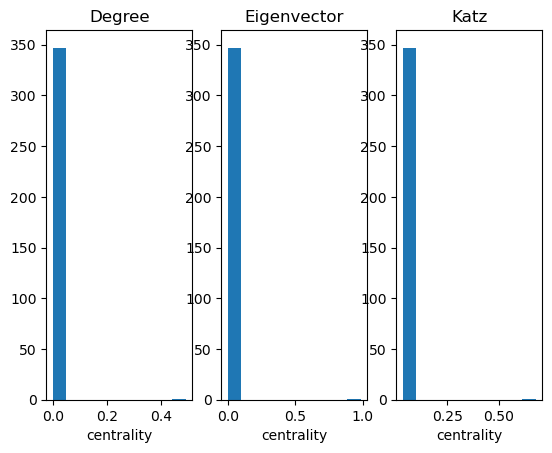

In [ ]:
# plot histograms
# degree centrality
plt.subplot(1,3,1)
plt.hist(list(lDegCentrality.values()))
plt.title('Degree')
plt.xlabel('centrality')

# eigenvector centrality
plt.subplot(1, 3, 2)
plt.hist(list(lEigenVectorCentrality.values()))
plt.title('Eigenvector')
plt.xlabel('centrality')
# katz centrality
plt.subplot(1, 3, 3)
plt.hist(list(lKatzCentrality.values()))
plt.title('Katz')
plt.xlabel('centrality')

plt.show()

The following code computes the SNA statistics/measures to do with centrality, clustering coefficient, connected components and bridges.

In [ ]:
# Update the node attributes with centrality

# eigenvector centrality, stored in node attribute 'eigen'
for nodeId, cent in lEigenVectorCentrality.items():
    networkGraph.nodes[nodeId]['eigen'] = float(cent)

# katz centrality, stored in node attribute 'katz'
for nodeId, cent in lKatzCentrality.items():
    networkGraph.nodes[nodeId]['katz'] = float(cent)

# Split sFileName to created modified file
sFileNameSplit = sFileName.split('.', 2)
sFileNameSplit = '.'.join(sFileNameSplit[:2])

# Write out graph to new file
nx.readwrite.write_graphml(networkGraph, sFileNameSplit + "_SNA.graphml", infer_numeric_types=True)


# Compute the other SNA measures specified in the lab

# compute clustering
# the networkx code is within format(...)
print('Global clustering coefficient/transitivit = {}'.format(nx.transitivity(networkGraph)))


# compute components
print('number of strongly connected components = {}'.format(nx.number_strongly_connected_components(networkGraph)))
print('number of weakly connected components = {}'.format(nx.number_weakly_connected_components(networkGraph)))


# compute bridges
print(list(nx.bridges(networkGraph.to_undirected())))


Global clustering coefficient/transitivit = 0
number of strongly connected components = 348
number of weakly connected components = 41
[('faeriesheep.bsky.social', 'triple-q.bsky.social'), ('mfelps.bsky.social', 'triple-q.bsky.social'), ('tayl1r.itch.io', 'triple-q.bsky.social'), ('tylernocturne.bsky.social', 'triple-q.bsky.social'), ('gooperdust.bsky.social', 'triple-q.bsky.social'), ('amysel.bsky.social', 'triple-q.bsky.social'), ('speycs.bsky.social', 'triple-q.bsky.social'), ('counterpillow.bsky.social', 'triple-q.bsky.social'), ('revlis-proto.bsky.social', 'triple-q.bsky.social'), ('alpha-mo-mega.bsky.social', 'triple-q.bsky.social'), ('sidoen.net', 'triple-q.bsky.social'), ('bladepuppy.bsky.social', 'triple-q.bsky.social'), ('brevvy.bsky.social', 'shubbabang.bsky.social'), ('elusive-bear.bsky.social', 'shubbabang.bsky.social'), ('shubbabang.bsky.social', 'zeforgotten.bsky.social'), ('shubbabang.bsky.social', 'princeraglan.bsky.social'), ('shubbabang.bsky.social', 'micholous.bsky.

## Community Detection
Using our modified Reply Graph

Code taken from week 9 as a basis

In [ ]:
import networkx as nx
# python-louvain
import community
import random
import csv

import matplotlib.pyplot as plt

# filename of graph to use 
sFileName = datasetPath + "communityReplyGraph.graphml"

In [ ]:
def dictToSetFormat(dComments, maxCommentNum):
    lSets = [set() for x in range(maxCommentNum)]
    for (name, clusId) in dComments.items():
        lSets[clusId].add(name)
    return lSets


In [33]:
replyGraph = nx.read_graphml(sFileName)

k = 2
lCpmComms = list(nx.algorithms.community.k_clique_communities(nx.to_undirected(replyGraph), k))
print("CPM communities found: ", len(lCpmComms))

dLouvainComms = community.best_partition(nx.to_undirected(replyGraph))
print("Louvain communities found: ", max(dLouvainComms.values()) + 1)

louvainCommNum = max([y for (x,y) in dLouvainComms.items()]) + 1
lLouvainComms = dictToSetFormat(dLouvainComms, louvainCommNum)

for clusId, lComms in enumerate(lCpmComms):
    for nodeId in lComms:
        replyGraph.nodes[nodeId]['cpmClusId'] = clusId

for clusId, lComms in enumerate(lLouvainComms):
    for nodeId in lComms:
        replyGraph.nodes[nodeId]['louvain'] = clusId



print("Saved to CPM_LOUVAIN_communityReplyGraph.graphml")

nx.readwrite.write_graphml(replyGraph, datasetPath + "CPM_LOUVAIN_communityReplyGraph.graphml", infer_numeric_types=True)


CPM communities found:  32
Louvain communities found:  44
Saved to CPM_LOUVAIN_communityReplyGraph.graphml


### Random Cascade
Week 10 workshop code as basis:

In [31]:
import time
import random
import numpy as np
import networkx as nx

This function performs the independent cascade.

In [32]:
def independentCascade(graph, trialNum, lSeed, activationProb):
    """
    Performs independent cascade over the input graph.  Results are stored in two output
    lists.

    @param graph: Input graph to perform cascade over.
    @param trialNum: The number of runs/trials to run.  The results are averaged over the
                    the trials/runs.
    @param lSeed: List of initial nodes to seed.  Range from 0 to number of nodes -1.
    @param activationProb: Activation probability on each edge.  All edges have the same
                    activation probability.

    @return: Two lists, lAvgActivationsPerNode and lAvgActivationsPerIteration.
            lAvgActivationsPerNode is a list with the size same as the number of nodes in
            the graph.  Each index of the list (starting with zero) corresponds directly
            to the associated node, and each entry represents the average number of activations
            over the trials/runs, and should lie in [0,1] range.
            lAvgActivationsPerIteration is a list with the size same as the number of trials/runs.
            Each index of the list corresponds to a trial/run, and each entry is the
            total number of active nodes in that trial/run.
    """

    # generate initial lists/vectors for the two output lists
    # This is set since we do not use integer ids for nodes we use the string names instead
    lAvgActivationsPerNode = {
    node: 0
    for node in graph.nodes()
    }
    lAvgActivationsPerIteration = []

    print('starting cascade run')
    # loop through the runs/trials
    for i in range(trialNum):
        print('Trial/run no. {}'.format(i))
        
        # list of active nodes
        setActive = set(lSeed)
        setLastActive = set(lSeed)
        setNewActive = set()
        # we keep looping until no more new activations
        while len(setLastActive) > 0:
            # for each active node, we try to influence its (unactived neighbours)
            for currNode in setLastActive:
                # check each neighbour
                for neighbour in graph.neighbors(currNode):
                    # we only want non-active neighbours
                    if neighbour not in setActive and neighbour not in setNewActive:
                        if random.random() < activationProb:
                            setNewActive.add(neighbour)

            # update last active
            setLastActive = setNewActive
            # extend active set
            setActive.update(setNewActive)
            # reset new active
            setNewActive = set()

        # update the output lists
        for x in setActive:
            lAvgActivationsPerNode[x] += 1

        # update with total number of activations
        lAvgActivationsPerIteration.append(len(setActive))

    # we average each entry in lAvgActivationsPerNode by number of runs/trials
    return {
        node: count / trialNum
        for node, count in lAvgActivationsPerNode.items()
    }, lAvgActivationsPerIteration


Independent cascade calculation on reply graph

In [37]:
# graph fileName
inputFile = "communityReplyGraph.graphml"
graphFile = nx.readwrite.read_graphml(datasetPath + inputFile)

# Independent cascade configuration
lSeed = list(graphFile.nodes())[:2]
trialNum = 10
activationProb = 0.5


lAvgActivationsPerNode, lAvgActivationsPerIteration = independentCascade(graphFile, trialNum, lSeed, activationProb)
print(lAvgActivationsPerNode)
print(lAvgActivationsPerIteration)
print('Average number of nodes activated = {} out of {}'.format(sum(lAvgActivationsPerIteration) / len(lAvgActivationsPerIteration), nx.number_of_nodes(graphFile)))


# Save to graph
# average activation per node for balanced tree,
# stored in node attribute 'avgAct'
for nodeName, avgActivation in lAvgActivationsPerNode.items():
    graphFile.nodes[nodeName]["avgAct"] = avgActivation

# Output modified graphs to respective files
nx.readwrite.write_graphml(graphFile, datasetPath + 'tree_' + inputFile, infer_numeric_types=True)



starting cascade run
Trial/run no. 0
Trial/run no. 1
Trial/run no. 2
Trial/run no. 3
Trial/run no. 4
Trial/run no. 5
Trial/run no. 6
Trial/run no. 7
Trial/run no. 8
Trial/run no. 9
{'faeriesheep.bsky.social': 1.0, 'mfelps.bsky.social': 1.0, 'tayl1r.itch.io': 0.0, 'tylernocturne.bsky.social': 0.0, 'gooperdust.bsky.social': 0.0, 'amysel.bsky.social': 0.0, 'speycs.bsky.social': 0.0, 'counterpillow.bsky.social': 0.0, 'revlis-proto.bsky.social': 0.0, 'alpha-mo-mega.bsky.social': 0.0, 'sidoen.net': 0.0, 'bladepuppy.bsky.social': 0.0, 'triple-q.bsky.social': 0.5, 'brevvy.bsky.social': 0.0, 'elusive-bear.bsky.social': 0.0, 'shubbabang.bsky.social': 0.0, 'zeforgotten.bsky.social': 0.0, 'princeraglan.bsky.social': 0.0, 'micholous.bsky.social': 0.0, '5eadubbz.bsky.social': 0.0, 'sallytrees.bsky.social': 0.0, 'sparkykadachi.bsky.social': 0.0, 'reactivecupid93.vtubers.social': 0.0, 'darkm3ss.bsky.social': 0.0, 'donorak.bsky.social': 0.0, 'culturecrave.co': 0.0, 'loopingworld.com': 0.0, 'chiyoseika.

# Part 2: Sentiment and Topic Analysis
Now that we understand the network within our dataset, we can perform sentiment and topic analysis to help us ultimatly solve the question posed earlier.

## Part 2.1: Sentiment Analysis

Due to the reception to generative AI across the internet as a whole, our hypothesis is that there will be an negative sentiment towards generative AI in video games.

In [ ]:
with open(datasetPath + "bluesky_posts.json", "r", encoding="utf-8") as file:
    data = json.load(file)

In [ ]:
#Data preprocessing functions
stop_words = set(stopwords.words('english')) - {'not', 'no'}
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # lowercase
    text = text.lower()
    
    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    #Change emojis to text representation
    text = emoji.demojize(text)
    text = text.replace(":", " ").replace("_", " ")

    #Remove all non letter characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # tokenize
    tokens = nltk.word_tokenize(text)
    
    # remove stopwords
    tokens = [w for w in tokens if w not in stop_words]
    
    # lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    
    return tokens

def handle_negation(tokens):
    result = []
    negate = False
    
    for word in tokens:
        if word in ['not', 'no', 'never']:
            negate = True
            continue
        
        if negate:
            result.append("not_" + word)
            negate = False
        else:
            result.append(word)
    
    return result

In [ ]:
dataset = pd.DataFrame(columns=["author", "post"])
datasetarr = []
for post in data["posts"]:
    author = post["author"]["handle"]
    text = post["text"]
    
    datasetarr.append({
        "author": author,
        "post": text
    })
    for comment in post["comments"]:
        author = comment["author"]["handle"]
        text = comment["text"]
        
        datasetarr.append({
            "author": author,
            "post": text
        })

dataset = pd.DataFrame(datasetarr)


In [ ]:
display(dataset.head())
display(dataset.info())
display(dataset.describe())

In [ ]:
emoji_counts = (Counter(c for text in dataset["post"] for c in text if c in emoji.EMOJI_DATA)).most_common(10)
print(tabulate.tabulate(emoji_counts, headers=["Emoji", "Count"], tablefmt="grid"))

In [ ]:
dataset = dataset.dropna(subset=["post"])
dataset = dataset.drop_duplicates(subset=["post"])

dataset["processed"] = dataset["post"].apply(preprocess)
dataset["processed"] = dataset["processed"].apply(handle_negation)
dataset["cleaned_post"] = dataset["processed"].apply(lambda tokens: " ".join(tokens))

In [ ]:
all_tokens = " ".join(dataset["cleaned_post"]).lower().split()
common_tokens = Counter(all_tokens).most_common(10)
print(tabulate.tabulate(common_tokens, headers=["Word", "Count"], tablefmt="grid"))
print(dataset["cleaned_post"].describe())

In [ ]:
sia = SentimentIntensityAnalyzer()

dataset["sentiment"] = dataset["cleaned_post"].apply(lambda text: sia.polarity_scores(text)["compound"])

def lable(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

dataset["sentiment_label"] = dataset["sentiment"].apply(lable)

dataset["sentiment"].hist(bins=20)
plt.title("Sentiment Score Distribution")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

From this histogram of result values from the Vadar model, we can see that there is quite a lot of "netural" values and there is more "positive" values than "negative" values.

In [ ]:
dataset["sentiment_label"].value_counts().plot(kind="bar")
plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.show()

The created bar chart confirms our findings from the histogram. This directly contradicts our hypothesis so we will attempt to confirm or deny these results using two different bert models. These will be Distilbert Base and Twitter Roberta Base.

In [ ]:
#bert_sentiment = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")
bert_sentiment = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
def get_bert_sentiment(text):
    result = bert_sentiment(text[:512])[0]
    return result["label"], result["score"]

dataset[["bert_label", "bert_score"]] = dataset["cleaned_post"].apply(lambda x: pd.Series(get_bert_sentiment(x)))

dataset['bert_label'] = dataset['bert_label'].str.lower()

dataset["bert_label"].value_counts().plot(kind="bar")
plt.title("BERT Sentiment Label Distribution")
plt.xlabel("BERT Sentiment Label")
plt.ylabel("Count")
plt.show()

In [ ]:
bert_sentiment1 = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")
def get_bert_sentiment1(text):
    result = bert_sentiment1(text[:512])[0]
    return result["label"], result["score"]

dataset[["bert_label1", "bert_score1"]] = dataset["cleaned_post"].apply(lambda x: pd.Series(get_bert_sentiment1(x)))
dataset['bert_label1'] = dataset['bert_label1'].str.lower()

dataset["bert_label1"].value_counts().plot(kind="bar")
plt.title("BERT Twitter Sentiment Label Distribution")
plt.xlabel("BERT Twitter Sentiment Label")
plt.ylabel("Count")
plt.show()

The results from both the Distilbert Base and the Twitter Roberta Base models clearly show that our inital assumption is correct unlike the Vadar model. This could be because of a number of factors but it is most likly due to the major difference in the models. Due to the correlation of results between Distilbert Base and Twitter Roberta Base, they are more likly to be correct for our dataset rather than the Vadar results and thus will be used to determine our final thoughts.

## Part 2.2: Topic Analysis

In [ ]:
def display_topics(model, featureNames, numTopWords):
    """
    Prints out the most associated words for each feature.

    @param model: lda model.
    @param featureNames: list of strings, representing the list of features/words.
    @param numTopWords: number of words to print per topic.
    """

    # print out the topic distributions
    for topicId, lTopicDist in enumerate(model.components_):
        print("Topic %d:" % (topicId))
        print(" ".join([featureNames[i] for i in lTopicDist.argsort()[:-numTopWords - 1:-1]]))

In [ ]:
def displayWordcloud(model, featureNames):
    """
    Displays the word cloud of the topic distributions, stored in model.

    @param model: lda model.
    @param featureNames: list of strings, representing the list of features/words.
    """

    # this normalises each row/topic to sum to one
    # use this normalisedComponents to display your wordclouds
    normalisedComponents = model.components_ / model.components_.sum(axis=1)[:, np.newaxis]
    
    topicNum = len(model.components_)
    # number of wordclouds for each row
    plotColNum = 3
    # number of wordclouds for each column
    plotRowNum = int(math.ceil(topicNum / plotColNum))

    for topicId, lTopicDist in enumerate(normalisedComponents):
        lWordProb = {featureNames[i] : wordProb for i,wordProb in enumerate(lTopicDist)}
        wordcloud = WordCloud(background_color='black')
        wordcloud.fit_words(frequencies=lWordProb)
        plt.subplot(plotRowNum, plotColNum, topicId+1)
        plt.title('Topic %d:' % (topicId+1))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")

    plt.show(block=True)

In [ ]:
# LDA parameters
# number of topics to discover (default = 10)
topicNum = 10
# maximum number of words to display per topic (default = 10)
# Answer to Exercise 1 (change from 10 to 15)
wordNumToDisplay = 15
# this is the number of features/words to used to describe our documents
# please feel free to change to see effect
featureNum = 1500

In [ ]:
# Count Vectorizer
tfVectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=featureNum, stop_words='english')
tf = tfVectorizer.fit_transform(dataset["cleaned_post"])
# extract the names of the features (in our case, the words)
tfFeatureNames = tfVectorizer.get_feature_names_out()

# LDA MODEL
# Run LDA (see documentation about what the arguments means)
ldaModel = LatentDirichletAllocation(n_components =topicNum, max_iter=10, learning_method='online').fit(tf)

In [ ]:
display_topics(ldaModel, tfFeatureNames, wordNumToDisplay)

In [ ]:
panel = pyLDAvis.lda_model.prepare(ldaModel, tf, tfVectorizer, mds='tsne')
pyLDAvis.display(panel)

In [ ]:
displayWordcloud(ldaModel, tfFeatureNames)